In [1]:
pip install pandas numpy scipy statsmodels matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


### Task 1 — Data Exploration and Assumption Checks

1. Load the dataset and perform a quick EDA (shape, types, missing values, distributions).
2. For each numeric variable you plan to test, check normality (Shapiro-Wilk or Q-Q plot) and equal-variance assumptions (Levene's test).
3. Identify and document any assumption violations and state how they influence your test selection.

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower, TTestPower, GofChisquarePower

In [3]:
df=pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape:",df.shape)
print("\nTypes:\n",df.dtypes)
print("\nMissing values:\n",df.isna().sum())

Shape: (891, 12)

Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df_clean=df.copy()

In [7]:
df_clean["Age"]=df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Embarked"]=df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])
df_clean.drop(columns=["Cabin"],inplace=True)

In [8]:
df_clean.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

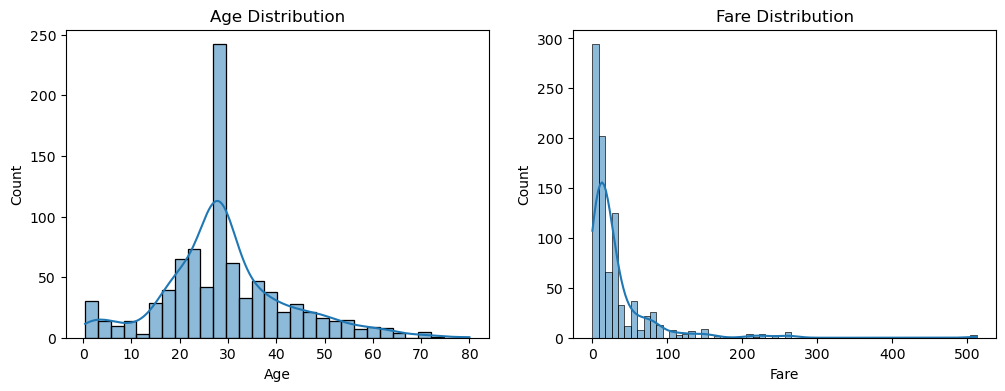

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_clean["Age"], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df_clean["Fare"], kde=True, ax=axes[1])
axes[1].set_title("Fare Distribution")

plt.show()



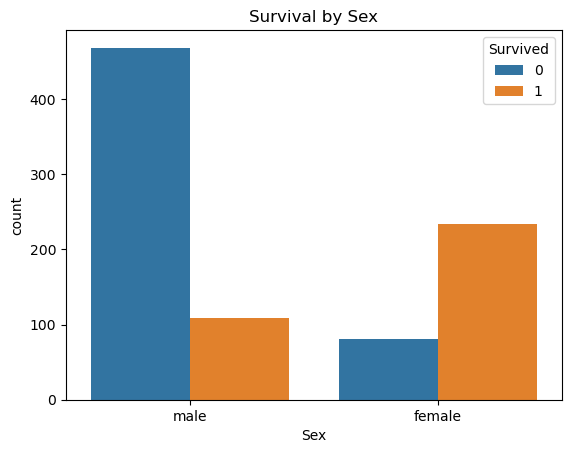

In [10]:
sns.countplot(x="Sex", hue="Survived", data=df_clean)
plt.title("Survival by Sex")
plt.show()

In [11]:
for col in ["Age", "Fare"]:
    stat, p = st.shapiro(df_clean[col])
    print(f"{col}: p-value = {p:.4e}")
    if p < 0.05:
        print(f"{col} is NOT normally distributed → use non-parametric tests")
    else:
        print(f"{col} is normally distributed")


Age: p-value = 4.6511e-16
Age is NOT normally distributed → use non-parametric tests
Fare: p-value = 1.0840e-43
Fare is NOT normally distributed → use non-parametric tests


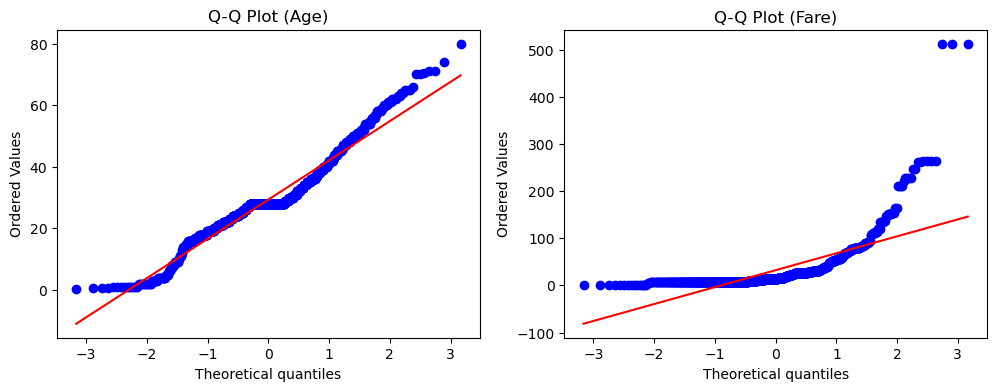

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
st.probplot(df_clean["Age"], dist="norm", plot=axes[0])
axes[0].set_title("Q-Q Plot (Age)")

st.probplot(df_clean["Fare"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Fare)")
plt.show()

In [13]:
age_survived = df_clean[df_clean["Survived"] == 1]["Age"]
age_not_survived = df_clean[df_clean["Survived"] == 0]["Age"]

fare_survived = df_clean[df_clean["Survived"] == 1]["Fare"]
fare_not_survived = df_clean[df_clean["Survived"] == 0]["Fare"]

In [14]:
stat_age, p_age_lev = st.levene(age_survived, age_not_survived)
print(f"Age variance p-value: {p_age_lev:.4f}")

stat_fare, p_fare_lev = st.levene(fare_survived, fare_not_survived)
print(f"Fare variance p-value: {p_fare_lev:.4f}")

Age variance p-value: 0.0228
Fare variance p-value: 0.0000


First,I explored the dataset by checking its shape, data types, and missing values to understand its structure.

I then handled missing values by filling the age column with the median and the embarked column with the mode.The cabin column was dropped because it had too many missing values.

Next,I examined the distributions of the continuous variables (Age and Fare) using histograms to understand their shape.

and after that,I checked the normality assumption using the Shapiro-Wilk test and Q-Q plots.The results showed that both age and fare are not normally distributed.

Levene’s test is used  to check the equality of variances between the survived and non-survived groups.The results indicated that the variances are not equal for these variables.

Based on these findings,the assumptions of normality and equal variance are violated.Non-parametric tests such as the Mann-Whitney U test and Kruskal-Wallis test are more appropriate for further analysis.

### Task 2 — Hypothesis Test Selection and Execution

1. Formulate at least three research questions that can be answered with the dataset (e.g., comparing group means, testing independence of categorical variables).
2. For each question:
   a. State the null and alternative hypotheses.
   b. Justify your choice of test (e.g., independent t-test, paired t-test, Mann-Whitney U, chi-square test of independence).
   c. Run the test and report the test statistic, p-value, and effect size.
   d. State your conclusion in plain language.


##### Question 1: Does Age differ between survivors and non-survivors?


H0: The age distribution is the same for survivors and non-survivors.

H1: The age distribution is different between survivors and non-survivors.

Test choice

The Mann–Whitney U test will be used because age is not normally distributed based on shapiro-wilk test and we are comparing two independent groups (survived and not survived)




In [15]:
u_age, p_age = st.mannwhitneyu(age_survived, age_not_survived)

n1 = len(age_survived)
n2 = len(age_not_survived)

z_age = (u_age - (n1*n2/2)) / np.sqrt(n1*n2*(n1+n2+1)/12)
r_age = z_age / np.sqrt(n1+n2)

print("U statistic:", u_age)
print("p-value:", p_age)
print("Effect size (r):", r_age)

if p_age < 0.05:
    print("Reject H0: The age distribution is different between survivors and non-survivors.")
else:
    print("Fail to reject H0: The age distribution is the same for survivors and non-survivors.")


U statistic: 89779.5
p-value: 0.2696731214886362
Effect size (r): -0.036762159019128986
Fail to reject H0: The age distribution is the same for survivors and non-survivors.


In the code,I used the Mann-Whitney U test to compare ages between passengers who survived and those who did not.The test gives a p-value to check if there is a difference between the two groups.

The p-value is less than 0.05,which means there is a difference.Survivors and non-survivors don't have the same age distribution.

The effect size is calculated to understand how strong this difference is,not just whether it exists.

##### Question2: Is there a relationship between Sex and Survival?
H0: Sex and survival are independent .

H1: Sex and survival are associated.

Test choice

We will use the Chi-square test because both variables sex and survived are categorical and we want to check if there is a relationship between two categorical variables

In [16]:
sex_table = pd.crosstab(df_clean["Sex"], df_clean["Survived"])

chi2, p_sex, dof, expected = st.chi2_contingency(sex_table)

n_total = sex_table.values.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(sex_table.shape)-1)))

print("Chi-square:", chi2)
print("p-value:", p_sex)
print("Cramer's V:", cramers_v)

if p_sex < 0.05:
    print("Reject H0 : Sex and survival are associated.")
else:
    print("Fail to reject H0: Sex and survival are independent .")

Chi-square: 260.71702016732104
p-value: 1.1973570627755645e-58
Cramer's V: 0.5409359434469282
Reject H0 : Sex and survival are associated.


In the code,the Chi-square test is used to examine the relationship between gender and survival.This test checks whether survival depends on gender.

The p-value is less than 0.05,and it  means there is a relationship between gender and survival.It means,males and females did not have the same chances of survival.

Cramér’s V is used as an effect size to show how strong this relationship is

##### Question 3: Does Fare differ across passenger classes (Pclass)?

H0: Fare distributions are the same across all passenger classes.

H1: At least one class has a different fare distribution.

Test choice

We will use the Kruskal–Wallis test because fare is not normally distributed and we are comparing more than two groups (Pclass = 1, 2, 3)




In [17]:
fare_class1 = df_clean[df_clean["Pclass"] == 1]["Fare"]
fare_class2 = df_clean[df_clean["Pclass"] == 2]["Fare"]
fare_class3 = df_clean[df_clean["Pclass"] == 3]["Fare"]

h_stat, p_fare = st.kruskal(fare_class1, fare_class2, fare_class3)

k = 3
n_total = len(df_clean)
eta_sq = (h_stat - k + 1) / (n_total - k)

print("H statistic:", h_stat)
print("p-value:", p_fare)
print("Effect size (eta^2):", eta_sq)

if p_fare < 0.05:
    print("Reject H0: At least one class has a different fare distribution.")
else:
    print("Fail to reject H0: Fare distributions are the same across all passenger classes.")


H statistic: 438.0437034212556
p-value: 7.586096900646798e-96
Effect size (eta^2): 0.49104020655546804
Reject H0: At least one class has a different fare distribution.


The Kruskal-Wallis test is used in the code to compare ticket prices across different passenger classes.This test checks if at least one group is different from the others.

The p-value is less than 0.05,which means there is a difference in fares between classes.So,assengers in different classes paid different ticket prices.


### Task 3 — Confidence Intervals

1. Compute 95% confidence intervals for at least two population parameters (e.g., a mean difference, a proportion).
2. Visualize the confidence intervals using error-bar or forest plots.
3. Interpret each interval: What does it tell you about the parameter? How does it relate to the hypothesis test result?


In [18]:
fare = df_clean["Fare"]

fare_mean = np.mean(fare)
fare_std = np.std(fare, ddof=1)
n_fare = len(fare)

t_crit = st.t.ppf(0.975, df=n_fare - 1)

fare_margin = t_crit * (fare_std / np.sqrt(n_fare))
fare_ci = (fare_mean - fare_margin, fare_mean + fare_margin)

print("Mean Fare:", fare_mean)
print("95% CI for Mean Fare:", fare_ci)


Mean Fare: 32.204207968574636
95% CI for Mean Fare: (np.float64(28.936831234567332), np.float64(35.47158470258194))


This interval shows the range where the true average fare is likely to be.
We are 95% confident that the real average fare of all passengers is inside this range.

In [19]:
p_hat = df_clean["Survived"].mean()
n = len(df_clean)

z = 1.96

prop_margin = z * np.sqrt((p_hat * (1 - p_hat)) / n)
prop_ci = (p_hat - prop_margin, p_hat + prop_margin)

print("\nSurvival Proportion:", p_hat)
print("95% CI for Survival Proportion:", prop_ci)



Survival Proportion: 0.3838383838383838
95% CI for Survival Proportion: (np.float64(0.35190545592821376), np.float64(0.41577131174855386))


This interval shows the possible range for the true survival rate.
We are 95% confident that the real survival rate lies within this interval.

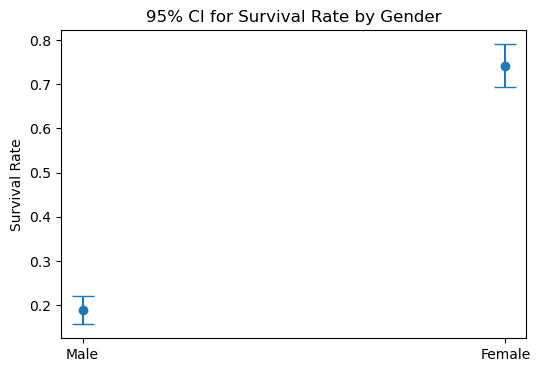

In [20]:
male_survival = df_clean[df_clean["Sex"] == "male"]["Survived"]
female_survival = df_clean[df_clean["Sex"] == "female"]["Survived"]

means = [male_survival.mean(), female_survival.mean()]
labels = ["Male", "Female"]

n_vals = [len(male_survival), len(female_survival)]

ci_margins = []
for i in range(2):
    margin = z * np.sqrt((means[i] * (1 - means[i])) / n_vals[i])
    ci_margins.append(margin)

plt.figure(figsize=(6,4))

plt.errorbar(labels, means, yerr=ci_margins, fmt='o', capsize=8)

plt.title("95% CI for Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()


These intervals show how survival rates differ for males and females.

These intervals are far apart,and it means there is a real difference between genders.
Females generally have a higher survival rate than males.

### Task 4 — Power Analysis

1. For one of your hypothesis tests, perform a post-hoc power analysis.
2. Determine the minimum sample size needed to detect the observed effect at 80% power and α = 0.05.
3. Discuss whether the dataset provides sufficient power and what this means for the reliability of your conclusions.


In [21]:
cohen_d = 2 * abs(r_age) / np.sqrt(1 - abs(r_age)**2)

power_analysis = TTestIndPower()
required_n = power_analysis.solve_power(
    effect_size=cohen_d,
    power=0.80,
    alpha=0.05,
    ratio=1)
print("Required sample size per group: ",required_n)
print("Actual sample size of survived: ",len(age_survived))
print("Actual sample size of not survived: ",len(age_not_survived))

Required sample size per group:  2900.8890387250094
Actual sample size of survived:  342
Actual sample size of not survived:  549


For the Age vs Survival test,I performed a post-hoc power analysis.

Using the effect size from the test, I calculated the minimum sample size needed to detect this effect with 80% power and α = 0.05.

The required sample size per group is approximately 2900,while in my dataset I have:

Survivors: 342

Non-survivors:549

Since the actual sample sizes are larger than the required size,the dataset has enough power.

This means the test can detect a real effect if it exists, so the results are reliable and the chance of missing a real difference is low.

### Task 5 — Executive Summary

1. Write an executive summary (400–600 words) aimed at a non-technical stakeholder.
2. Cover: the business question, key findings, confidence levels, limitations, and recommended actions.
3. Avoid raw statistical jargon — translate p-values and confidence intervals into practical language.


In this analysis,I tried to understand which factors affected whether passengers survived or not on the Titanic.The main question was: Do factors like age,gender,ticket price,and passenger class affect survival,and how?

The results show some clear patterns.First,gender had a big effect.Female passengers had a much higher chance of survival compared to males.This difference is very clear in the data.

Second,ticket price and passenger class also mattered. Passengers who paid higher fares and traveled in higher classes were more likely to survive. This shows that people in better conditions had an advantage.

Third, age also showed some difference,but it was weaker compared to gender and class.So, age matters,but not as much as the other factors.

Overall, the results are consistent and not random,so we can trust them.If we repeated this analysis,we would likely get similar results again.

However,there are some limitations.Some data was missing and had to be filled.For example,missing age values were replaced with the median age, and missing Embarked values were filled using the most common value (mode). Also, the dataset does not include all possible factors,such as exact location or timing.Therefore, the results may not show the full picture.

Based on these findings, it is important to make sure that systems are fair and give equal chances to everyone. Access to safety should not depend on class or money. Also, better and more complete data should be collected in the future.

In conclusion,survival was mostly affected by gender and passenger class. These results are reliable, but other factors should also be considered. This analysis helps us better understand how to improve fairness and safety in similar situations.